### Statistics in Machine Learning

### Role of Statistics in Machine Learning
Statistics helps us collect, analyze, summarize, and interpret data. In Machine Learning, statistics is used to understand data, preprocess it, build models, and evaluate their performance.

### Data Cleaning
Data cleaning is the process of identifying and correcting inaccurate, duplicate, or inconsistent data before training a machine learning model.

Example:

A customer dataset contains duplicate records and invalid ages such as -5 or 150. These values should be corrected or removed.

In [2]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Arun", "Bala", "Arun"],
    "Age": [25, -5, 25],
    "City": ["Chennai", "chennai", "Chennai"]
})

# Remove duplicate rows
df = df.drop_duplicates()

# Replace invalid ages with missing values
df.loc[df["Age"] < 0, "Age"] = None

# Standardize city names
df["City"] = df["City"].str.title()

print(df)

   Name   Age     City
0  Arun  25.0  Chennai
1  Bala   NaN  Chennai


### Common cleaning operations:

* Remove duplicates.
* Correct data types.
* Fix spelling and inconsistent labels.
* Identify invalid values.
* Handle missing values and outliers.

**AI/ML example**: Cleaning customer records before training a model to predict customer churn.

**Interpretation**: Clean data helps produce more reliable analysis and model predictions. It does not, by itself, guarantee a good model.

### Missing Value Handling
Missing value handling means deciding what to do when a dataset contains unavailable values, represented by NaN, None, or blank fields.
Copy and paste this table directly into Excel, Google Docs, Notion, or your Markdown notes.

| Method                 | How it works                                             | When useful                                                 |
| ---------------------- | -------------------------------------------------------- | ----------------------------------------------------------- |
| Drop rows              | Remove records with missing values                       | When only a few rows are affected                           |
| Mean imputation        | Replace missing values with the average                  | Numerical data without strong skew or extreme outliers      |
| Median imputation      | Replace missing values with the middle value             | Numerical data with outliers or skew                        |
| Mode imputation        | Replace missing values with the most frequent value      | Categorical data                                            |
| Forward fill           | Replace missing values with the previous available value | Some time-series data                                       |
| Model-based imputation | Predict missing values using other features              | Complex datasets with useful relationships between features |


In [12]:
import pandas as pd

df = pd.DataFrame({
    "Age": [25, None, 35, 40],
    "Salary": [30000, 40000, None, 50000],
    "City": ["Chennai", "Salem", None, "Madurai"]
})

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())
df["City"] = df["City"].fillna(df["City"].mode()[0])

print(df)

    Age   Salary     City
0  25.0  30000.0  Chennai
1  35.0  40000.0    Salem
2  35.0  40000.0  Chennai
3  40.0  50000.0  Madurai


**AI/ML example**: Filling missing salary values before training a salary prediction model.

**Important**: Calculate imputation values from the training data only, then apply them to validation and test data. This avoids data leakage.

### Outlier Detection

An outlier is a data point that is unusually far from the rest of the observations.

Example: Salaries are ₹25,000, ₹28,000, ₹30,000, ₹32,000, and ₹5,00,000. The last value may be an outlier.

#### Common detection methods

### IQR method

Calculate IQR=Q3−Q1

. Values below Q1−1.5(IQR) or above Q3+1.5(IQR) are flagged.

### Z-score method
z=x−μ/σ
Values with ∣z∣>3 are often flagged when the data is approximately normal.

In [16]:
import pandas as pd

salary = pd.Series([25000, 28000, 30000, 32000, 500000])

q1 = salary.quantile(0.25)
q3 = salary.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = salary[(salary < lower) | (salary > upper)]
print(outliers)

4    500000
dtype: int64


**AI/ML example**: Detecting unusual bank transactions or identifying abnormal machine sensor readings.

**Interpretation**: An outlier could be a data-entry error, fraud, or a genuine high-value observation. Investigate before removing it.

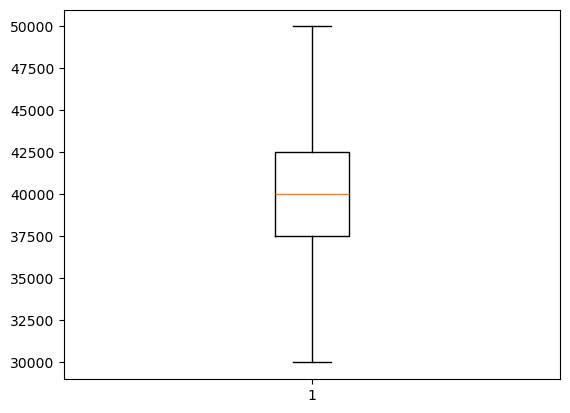

In [21]:
import matplotlib.pyplot as plt

plt.boxplot(df["Salary"])
plt.show()

### Feature Engineering
Feature engineering is the process of creating new input variables or transforming existing variables to help a Machine Learning model learn useful patterns.

Example: A dataset contains a customer's date of joining. We can create a new feature called Years_Of_Experience.

In [26]:
import pandas as pd

df = pd.DataFrame({
    "Experience_Years": [1, 3, 5],
    "Salary": [20000, 35000, 50000]
})

df["Experience_Level"] = df["Experience_Years"].apply(
    lambda x: "Fresher" if x < 2
    else "Mid-Level" if x < 5
    else "Experienced"
)

print(df)

   Experience_Years  Salary Experience_Level
0                 1   20000          Fresher
1                 3   35000        Mid-Level
2                 5   50000      Experienced


### Common feature engineering techniques:

* **Date features:** Extract month, year, weekday, or customer tenure.
* **Interaction features:** Multiply or combine related variables.
* **Binning:** Convert age into groups such as young, adult, and senior.

* **Encoding:** Convert categories into numerical representations.

* **Domain-specific features:** Calculate purchase frequency, average order value, or debt-to-income ratio.

**AI/ML example:** In a customer churn model, create a feature representing the number of days since the customer's last purchase.

**Interpretation:** Useful features can improve model performance, but irrelevant or leakage-prone features can make it worse.

### Feature Scaling
Feature scaling adjusts numerical features to comparable scales so that variables with large numerical values do not disproportionately affect certain algorithms.
For example:
Age: 25
Salary: 50,000

Salary has a much larger numerical scale than age.

Common scaling methods
### Standardization (StandardScaler)

z=x−μ/σ
	
Transforms data to approximately mean 0 and standard deviation 1.

Useful for: Logistic Regression, SVM, PCA, K-Means.

Min-Max Scaling (MinMaxScaler)

X′=x−xmin/xmax−xmin

Usually transforms values to the range 0 to 1.

Useful when a bounded numerical range is desired, including some neural network workflows.

In [41]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.DataFrame({
    "Age": [20, 30, 40],
    "Salary": [20000, 40000, 60000]
})

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

print(standard_scaler.fit_transform(df))
print(minmax_scaler.fit_transform(df))

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


**AI/ML example:** Scaling age and annual income before K-Means clustering customers.
**Important:** Fit the scaler on training data only. Apply the same fitted scaler to test and production data.

### Data Normalization

The term normalization can mean different things in different contexts. In many introductory Machine Learning courses, it means rescaling features to a common range, often 0–1. In other contexts, it means scaling each sample to a unit norm.

Min-max normalization example:

Suppose the minimum age is 20 and the maximum age is 60. For age 40:

x′= 40−20/60−20

=0.5

The normalized age is 0.5.

In [47]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

X = np.array([[20], [40], [60]])

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print(X_normalized)

[[0. ]
 [0.5]
 [1. ]]


### Model Evaluation
Model evaluation measures how well a trained model performs on data it has not seen during training.

### regression metrics

Metric  -  Meaning
* MAE - Average absolute prediction error
* MSE - Average squared prediction error
* RMSE - Square root of MSE; in the target's units
* R2 - Measures improvement over predicting the target mean, relative to total variation

### Classification metrics
Metric - Meaning
* Accuracy - Fraction of predictions that are correct
* Precision - Of predicted positives, how many are actually positive?
* Recall - Of actual positives, how many were detected?
* F1-score - Harmonic mean of precision and recall
* ROC-AUC - Measures ranking ability across classification thresholds

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=200,
    n_features=3,
    noise=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2:", r2_score(y_test, predictions))

MAE: 13.864257365888221
R2: 0.9667410895959422


Interpretation: Lower MAE and RMSE generally indicate better regression predictions. An R2
 closer to 1 usually indicates a better fit, but evaluation must consider the data, baseline, and business objective.

For imbalanced classification, accuracy alone can be misleading. For example, if only 1% of transactions are fraudulent, a model that predicts every transaction as legitimate gets 99% accuracy but detects no fraud.

### inear Regression
Linear Regression is a supervised Machine Learning algorithm used to predict a continuous numerical value.
Examples: salary prediction, house-price prediction, and sales forecasting.

The simple linear regression equation is:


^y	=b0+b1x

x: input feature

^y :predicted value

b0: intercept

b1: coefficient or slope

In [56]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Experience in years
X = np.array([[1], [2], [3], [4], [5]])

# Salary in thousands of rupees
y = np.array([20, 25, 30, 35, 40])

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[6]])

print("Predicted salary:", prediction[0], "thousand rupees")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Predicted salary: 45.0 thousand rupees
Slope: 5.000000000000001
Intercept: 14.999999999999996


Expected prediction: approximately 45 thousand rupees.

Business example: Predicting monthly sales based on advertising expenditure.

Advantages: Simple, interpretable, and fast.

Limitations: A basic linear model may not capture nonlinear relationships, and extreme outliers can strongly affect its fitted coefficients.

Interpretation: The slope represents the predicted change in the target for a one-unit increase in the feature, holding other features constant in multiple linear regression.

### Logistic Regression
Logistic Regression is a supervised algorithm primarily used for classification. Despite its name, it predicts class probabilities rather than ordinary continuous outcomes.

Examples: loan default prediction, customer churn, and spam detection.

It uses the sigmoid function:

P(y=1∣x)=1/1+e−z
where z=b0+b1
	​

x in the simple case.

The output probability is between 0 and 1. A classification threshold, often 0.5, can turn that probability into a class prediction.

In [62]:
from sklearn.linear_model import LogisticRegression

# [Hours studied]
X = [[1], [2], [3], [4], [5], [6]]
# 0 = fail, 1 = pass
y = [0, 0, 0, 1, 1, 1]

model = LogisticRegression()
model.fit(X, y)

probability = model.predict_proba([[4]])[0][1]
prediction = model.predict([[4]])[0]

print("Probability of passing:", probability)
print("Predicted class:", prediction)

Probability of passing: 0.6365629265347537
Predicted class: 1


Business example: Predicting whether a customer will repay a loan.

Advantages: Fast, interpretable, and provides probabilities.

Limitations: The standard model assumes a linear relationship between features and the log-odds. Nonlinear patterns may require feature engineering or another algorithm.

Interpretation: A probability of 0.8 means the model estimates an 80% chance of the positive class, assuming the model is appropriately calibrated. It is not a guarantee.

| Feature         | Linear Regression | Logistic Regression                  |
| --------------- | ----------------- | ------------------------------------ |
| Purpose         | Regression        | Classification                       |
| Output          | Numerical value   | Class probability                    |
| Example         | Predict salary    | Predict pass/fail                    |
| Typical metrics | MAE, RMSE, R²     | Precision, Recall, F1-score, ROC-AUC |


### Naive Bayes
Naive Bayes is a supervised classification algorithm based on Bayes' theorem. It assumes that features are conditionally independent given the class.

Bayes' theorem:

P(A∣B)= P(B∣A)P(A)/P(B)

Here, the model estimates the probability of a class given the observed features.

Types of Naive Bayes

* Gaussian Naive Bayes: For continuous features modeled using Gaussian distributions.
* Multinomial Naive Bayes: Commonly used for word counts and text classification.
* Bernoulli Naive Bayes: Often used for binary features, such as whether a word appears in a message.

In [75]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

messages = [
    "win money now",
    "claim your free prize",
    "meeting at office",
    "project meeting tomorrow"
]

labels = ["spam", "spam", "not spam", "not spam"]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(messages)

model = MultinomialNB()
model.fit(X, labels)

new_message = vectorizer.transform(["free money prize"])
print(model.predict(new_message))

['spam']


Business example: Classifying customer feedback as positive, negative, or neutral, after preparing appropriate training labels.

AI/ML example: Spam filtering, document classification, and simple text categorization.

Advantages: Fast, works well with many text features, and can perform well with relatively small datasets.

Limitations: The independence assumption is often unrealistic, and probability estimates may be poorly calibrated.

Interpretation: The model predicts the class with the highest estimated posterior probability. Its predictions depend on the training examples and chosen feature representation.

### Clustering
Clustering is an unsupervised Machine Learning technique that groups similar data points without requiring predefined target labels.

Example: Grouping customers according to purchasing behavior.

### K-Means clustering

K-Means divides the dataset into K clusters by assigning each observation to a nearby centroid and updating the centroids iteratively.

In [85]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.DataFrame({
    "Annual_Spending": [10, 12, 15, 80, 85, 90],
    "Visits": [1, 2, 2, 8, 9, 10]
})

scaler = StandardScaler()
X = scaler.fit_transform(df)

model = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

print(df)

   Annual_Spending  Visits  Cluster
0               10       1        0
1               12       2        0
2               15       2        0
3               80       8        1
4               85       9        1
5               90      10        1


D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Business example: Segmenting customers into low-spending and high-spending groups.

Other clustering algorithms:

DBSCAN: Identifies dense groups and can mark noise points.

Hierarchical clustering: Builds a hierarchy of nested clusters.

Advantages: Discovers patterns without labeled outcomes.

Limitations: K-Means requires choosing K, can be affected by outliers, and works best when clusters suit its distance-based assumptions.

Interpretation: Cluster numbers such as 0 and 1 are arbitrary identifiers, not rankings. Inspect cluster profiles to understand their meaning.

### Principal Component Analysis (PCA)

PCA is an unsupervised dimensionality reduction technique that transforms correlated numerical features into a smaller set of uncorrelated variables called principal components.

Suppose a dataset contains 50 numerical features. PCA might represent much of its variation using 10 principal components.

How PCA works

* Prepare numerical features and usually standardize them.
* Find directions of maximum variance in the data.
* Rank those directions by explained variance.
* Keep the desired number of principal components.
* Transform the data into the reduced representation.

In [92]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_iris()
X = data.data

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance retained:",
      pca.explained_variance_ratio_.sum())

Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance: [0.72962445 0.22850762]
Total variance retained: 0.9581320720000164


The Iris dataset starts with 4 features and is reduced to 2 principal components.

Business example: Simplifying many correlated financial indicators into a smaller number of dimensions for exploration.

AI/ML example: Reducing the number of input features before clustering or visualizing high-dimensional data.

Advantages: Can reduce redundancy, speed up downstream processing, and make visualization easier.

Limitations: Components may be difficult to interpret, and PCA can discard useful information, particularly information relevant to the prediction target.

Important: Standardize features when their scales differ substantially. Fit PCA on the training data only to avoid leakage.

Interpretation: Explained variance tells you how much of the dataset's overall variation each component captures. High explained variance does not necessarily mean better predictive performance.

### Recommendation Systems
A recommendation system suggests products, movies, music, or other items that a user may like based on preferences, behavior, or item characteristics.
Examples: Netflix movie suggestions, YouTube video recommendations, and online shopping recommendations.

#### Content-based filtering

Recommends items similar to those a user previously liked.
Example: If a user likes science-fiction films, recommend other science-fiction films.
Uses: Item attributes such as genre, description, brand, or category.

In [101]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies = pd.DataFrame({
    "title": [
        "Space Adventure",
        "Galaxy Mission",
        "Romantic Story",
        "Space Journey"
    ],
    "description": [
        "space science fiction adventure",
        "galaxy space science fiction",
        "romance love drama",
        "space adventure exploration"
    ]
})

vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(movies["description"])

similarity = cosine_similarity(features)

target = movies.index[movies["title"] == "Space Adventure"][0]

scores = list(enumerate(similarity[target]))
scores = sorted(scores, key=lambda item: item[1], reverse=True)

for idx, score in scores[1:3]:
    print(movies.iloc[idx]["title"], round(score, 3))

Galaxy Mission 0.673
Space Journey 0.479


| Problem                          | Suitable Technique                 |
| -------------------------------- | ---------------------------------- |
| Incorrect or duplicate records   | Data Cleaning                      |
| Missing ages or salaries         | Missing Value Handling             |
| Unusually high transactions      | Outlier Detection                  |
| Creating useful model inputs     | Feature Engineering                |
| Features with different scales   | Feature Scaling                    |
| Rescaling values to 0–1          | Min-Max Normalization              |
| Measuring model performance      | Model Evaluation                   |
| Predicting house prices          | Linear Regression                  |
| Predicting pass/fail             | Logistic Regression                |
| Spam email classification        | Naive Bayes                        |
| Customer segmentation            | Clustering                         |
| Reducing many numerical features | PCA (Principal Component Analysis) |
| Suggesting movies or products    | Recommendation Systems             |
